In [241]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import math


In [242]:
df = pd.read_csv('odds_2022-2023_v2.csv')
df = df.drop('Unnamed: 0',axis=1)
pd.set_option('future.no_silent_downcasting', True)

In [243]:
def calc_synth(odds):
    synth = 0
    for term in odds:
        if not math.isnan(term):
            synth = 1/(1/synth +1/term) if synth != 0 else term
    if np.isnan(odds).all():
        return math.nan
    else:
        return max(1,synth)
print(calc_synth([5,4,4,6]))

1.153846153846154


In [244]:
goals = pd.read_csv("goals_2022-2023.csv")
goals['Half Time'] = '0'
goals['Goal Scored'] = 'Yes'
goals['date'] = goals['date'].str[:10]

In [245]:
matches = df[['Home Team','Away Team']].drop_duplicates()
matches['match id'] = matches['Home Team']+'_'+matches['Away Team']
matches_list = matches['match id'].tolist()
zipped_matches = list(zip(matches['Home Team'],matches['Away Team']))

In [246]:
#function to create dataframe for a single match
def match_df(home,away,df):
    match_odds = df[(df['Home Team']==home)&(df['Away Team']==away)].copy()

    norm_mins = [(x,0,0) for x in range(0,91)]
    match_odds['time key'] = list(zip(match_odds['Elapsed Time'].astype(int),match_odds['Added Time'].astype(int),match_odds['Half Time'].astype(int)))
    extra_times = set(match_odds['time key'])-set(norm_mins)
    all_times = sorted(norm_mins+list(extra_times))
    new_df = pd.DataFrame(all_times,columns = ['Elapsed Time','Added Time','Half Time'])
    new_df['time key'] = list(zip(new_df['Elapsed Time'].astype(int),new_df['Added Time'].astype(int),new_df['Half Time'].astype(int)))

    
    under = match_odds[match_odds['Selection']=='Under 2.5 Goals'].copy()
    over = match_odds[match_odds['Selection']=='Over 2.5 Goals'].copy()
    exact_1_1 = match_odds[match_odds['Selection']=='1 - 1'].copy()
    exact_2_0 = match_odds[match_odds['Selection']=='2 - 0'].copy()
    exact_0_2 = match_odds[match_odds['Selection']=='0 - 2'].copy()
    exact_1_0 = match_odds[match_odds['Selection']=='1 - 0'].copy()
    exact_0_1 = match_odds[match_odds['Selection']=='0 - 1'].copy()
    exact_0_0 = match_odds[match_odds['Selection']=='0 - 0'].copy()

    markets = {'Under 2.5 Odds':under,'Over 2.5 Odds':over, '1-1 Odds':exact_1_1,'2-0 Odds':exact_2_0,'0-2 Odds':exact_0_2,'1-0 Odds':exact_1_0,'0-1 Odds':exact_0_1,'0-0 Odds':exact_0_0}
    for market in markets:
        new_df = new_df.merge(markets[market][['time key','Last Traded Price']],on='time key',how ='left')
        new_df = new_df.rename(columns={'Last Traded Price':market})
        still_live = new_df[market].notna() & (new_df[market]!= 1000)
        if still_live.any():
            last_live_idx = still_live[::-1].idxmax()
            new_df.loc[last_live_idx+1:,market]= 1000
        new_df[market]=new_df[market].ffill()
        new_df[market]=new_df[market].bfill()
        new_df.replace(1000.0, np.nan, inplace=True)

    #new_df['Synthetic']=1/(1/new_df['1-1 Odds']+1/new_df['2-0 Odds']+1/new_df['0-2 Odds']+1/new_df['1-0 Odds']+1/new_df['0-1 Odds']+1/new_df['0-0 Odds'])
    new_df['Synthetic']=new_df.apply(lambda row: calc_synth([row['1-1 Odds'],row['2-0 Odds'],row['0-2 Odds'],row['1-0 Odds'],row['0-1 Odds'],row['0-0 Odds']]),axis=1)
    
    new_df.loc[new_df['Under 2.5 Odds']==1000 | np.isnan(new_df['Under 2.5 Odds']),['Synthetic']]=math.nan
    new_df.loc[np.isnan(new_df['Synthetic']),['Under 2.5 Odds']]=math.nan
    new_df = new_df.rename(columns={'Under 2.5 Odds':'Real'})

    goals2 = goals[(goals['Home Team']==home)&(goals['Away Team']==away)].copy()
    goals2['time key'] = list(zip(goals2['Elapsed Time'].astype(int),goals2['Added Time'].astype(int),goals2['Half Time'].astype(int)))

    new_df = new_df.merge(goals2[['time key','Goal Scored','Player','Goal Type','Score']],on='time key',how ='left')
    new_df['Score']=new_df['Score'].ffill()
    new_df['Score'] = new_df['Score'].infer_objects(copy=False)
    new_df['Score']=new_df['Score'].fillna('0-0')
    new_df['Goal Scored']=new_df['Goal Scored'].fillna('No')

    new_df['Back'] = new_df.apply(lambda row: 'Real' if row['Real']>=row['Synthetic'] else 'Synthetic',axis = 1)
    new_df['Lay'] = new_df.apply(lambda row: 'Synthetic' if row['Real']>=row['Synthetic'] else 'Real',axis=1)
    new_df['Back Odds'] = new_df.apply(lambda row: max(row['Real'],row['Synthetic']),axis=1)
    new_df['Lay Odds'] = new_df.apply(lambda row: min(row['Real'],row['Synthetic']),axis=1)

    new_df['Lay Stake']= new_df.apply(lambda row: 100/((row['Lay Odds']-0.02)/(0.98*row['Back Odds']+0.02)+row['Lay Odds']-1),axis=1).round(1)
    new_df['Back Stake'] = new_df.apply(lambda row: 100/(1+(row['Lay Odds']-1)*(0.98*row['Back Odds']+0.02)/(row['Lay Odds']-0.02)), axis=1).round(1)
    new_df['Real Stake']=new_df.apply(lambda row: -1*row['Lay Stake'] if row['Lay']=='Real' else row['Back Stake'],axis=1)
    new_df['Synth Stake']=new_df.apply(lambda row: -1*row['Lay Stake'] if row['Lay']=='Synthetic' else row['Back Stake'],axis=1)
    

    new_df['Profit']=(0.98*new_df['Lay Stake']-new_df['Back Stake']).round(2)

    def format_time(row):
        if row['Half Time']>0:
            return f'HT{row['Half Time']}'
        elif row['Added Time']>0:
            return f"{row['Elapsed Time']}+{row['Added Time']}"
        else: 
            return f"{row['Elapsed Time']}"

    new_df['plot label'] = new_df.apply(format_time,axis=1)
    df_lite = new_df[['plot label','time key','Real', 'Synthetic','Back','Lay', 'Back Odds', 'Lay Odds', 'Score','Back Stake','Lay Stake','Real Stake', 'Synth Stake','Profit','Goal Scored']]
    return df_lite #new_df[['Score','Real','Synthetic','1-1 Odds','2-0 Odds','0-2 Odds','1-0 Odds','0-1 Odds','0-0 Odds','Profit']]
test = match_df('Southampton','Brentford',df)
test.tail(50)

,plot label,time key,Real,Synthetic,Back,Lay,Back Odds,Lay Odds,Score,Back Stake,Lay Stake,Real Stake,Synth Stake,Profit,Goal Scored
68,52,"(52, 0, 0)",1.50,1.492772,Real,Synthetic,1.500000,1.492772,0-1,66.7,67.5,66.7,-67.5,-0.55,No
69,53,"(53, 0, 0)",1.49,1.493683,Synthetic,Real,1.493683,1.490000,0-1,66.9,67.5,-67.5,66.9,-0.75,No
70,54,"(54, 0, 0)",1.46,1.481393,Synthetic,Real,1.481393,1.460000,0-1,68.0,69.5,-69.5,68.0,0.11,No
71,55,"(55, 0, 0)",1.44,1.463848,Synthetic,Real,1.463848,1.440000,0-1,68.9,70.6,-70.6,68.9,0.29,No
72,56,"(56, 0, 0)",1.43,1.416151,Real,Synthetic,1.430000,1.416151,0-1,70.2,71.5,70.2,-71.5,-0.13,No
73,57,"(57, 0, 0)",1.41,1.377232,Real,Synthetic,1.410000,1.377232,0-1,72.0,74.3,72.0,-74.3,0.81,No
74,58,"(58, 0, 0)",1.38,1.389674,Synthetic,Real,1.389674,1.380000,0-1,72.1,73.3,-73.3,72.1,-0.27,No
75,59,"(59, 0, 0)",1.37,1.365033,Real,Synthetic,1.370000,1.365033,0-1,73.0,74.0,73.0,-74.0,-0.48,No
76,60,"(60, 0, 0)",1.36,1.388190,Synthetic,Real,1.388190,1.360000,0-1,72.9,75.1,-75.1,72.9,0.70,No
77,61,"(61, 0, 0)",1.35,1.356164,Synthetic,Real,1.356164,1.350000,0-1,73.8,74.9,-74.9,73.8,-0.40,No


In [ ]:
'''#signal size finder
def profit_finder(row):
    #
    b, l = max(row['Real'],row['Synthetic']), min(row['Real'],row['Synthetic'])
    row['Back'] = row['Real'] if row['Real']>=row['Synthetic'] else row['Synthetic']
    row['Lay'] = row['Synthetic'] if row['Real']>=row['Synthetic'] else row['Real']
    x_l = 100/((l-0.02)/(0.98*b+0.02)+l-1)
    x_b = x_l*(0.98*b+0.02)/(l-0.02)
    profit = 0.98*x_l-x_b
    row['back stake'], row['lay stake'], row['profit signal'] = x_b, x_l, profit
def signal_finder(df):
    df = df.rename(columns={'Under 2.5 Odds':'Real'})
    df['brls'] = (0.98**2)*df['Real']+1.98*0.02-df['Synthetic']
    df['bslr'] = (0.98**2)*df['Synthetic']+1.98*0.02-df['Real']
    df['signal'] = df.apply(lambda x: (x['brls']-x['bslr']+1/1000)/abs(x['brls']-x['bslr']+1/1000)*max(x['brls'], x['bslr'],0), axis=1)
    return df
test2 = test.apply(profit_finder,axis=1)
test2.head()'''

0    None
1    None
2    None
3    None
4    None
dtype: object

In [99]:
'''def calc_stake(stake_type,r,s,B,back_real,signal):
    if not signal:
        return 0
    elif back_real:
        synth_stake = B / ((s-0.02)/(0.98*r+0.02)+s-1)
        real_stake = synth_stake*(s-0.02)/(0.98*r+0.02)
    else:
        real_stake = B / ((r-0.02)/(0.98*s+0.02)+r-1)
        synth_stake = real_stake*(r-0.02)/(0.98*s+0.02)
    if stake_type == 'Real':
        return real_stake
    else:
        return synth_stake


test2['real stake'] = test2.apply(lambda x: calc_stake('Real',x['Real'],x['Synthetic'],100,x['brls']>0,abs(x['signal'])>0),axis=1)
test2['synth stake'] = test2.apply(lambda x: calc_stake('Synth',x['Real'],x['Synthetic'],100,x['brls']>0,abs(x['signal'])>0),axis=1)
test2.tail()'''

"def calc_stake(stake_type,r,s,B,back_real,signal):\n    if not signal:\n        return 0\n    elif back_real:\n        synth_stake = B / ((s-0.02)/(0.98*r+0.02)+s-1)\n        real_stake = synth_stake*(s-0.02)/(0.98*r+0.02)\n    else:\n        real_stake = B / ((r-0.02)/(0.98*s+0.02)+r-1)\n        synth_stake = real_stake*(r-0.02)/(0.98*s+0.02)\n    if stake_type == 'Real':\n        return real_stake\n    else:\n        return synth_stake\n\n\ntest2['real stake'] = test2.apply(lambda x: calc_stake('Real',x['Real'],x['Synthetic'],100,x['brls']>0,abs(x['signal'])>0),axis=1)\ntest2['synth stake'] = test2.apply(lambda x: calc_stake('Synth',x['Real'],x['Synthetic'],100,x['brls']>0,abs(x['signal'])>0),axis=1)\ntest2.tail()"

In [100]:
'''#analysing signal size
test3 = test2[test2['signal']!=0][['time key','signal','real stake','synth stake','Score']]
test3.tail(50)'''

"#analysing signal size\ntest3 = test2[test2['signal']!=0][['time key','signal','real stake','synth stake','Score']]\ntest3.tail(50)"

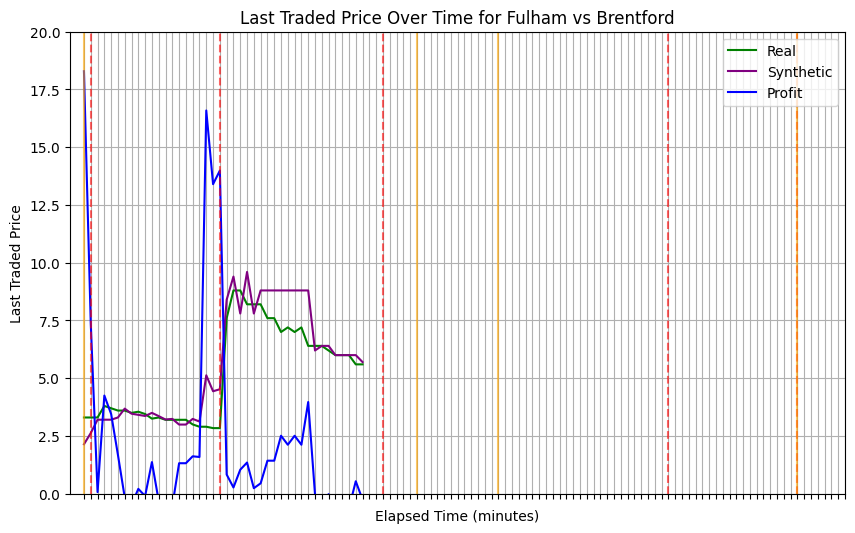

In [213]:
#graph plot function
def plot_signal(new_df,home,away):
    plt.figure(figsize=(10, 6))
    
    plt.plot('plot label', 'Real', data =new_df ,linestyle='-', color='green', label='Real')
    plt.plot('plot label', 'Synthetic', data =new_df, linestyle='-', color='purple', label='Synthetic')

    plt.plot('plot label', 'Profit', data =new_df ,linestyle='-', color='blue', label='Profit')
    #plt.plot('plot label', 'Synthetic', data =new_df, linestyle='-', color='purple', label='Synthetic')

    plt.xticks(new_df['plot label'],'')
    plt.ylim(bottom = 0, top=20)
    plt.grid()

    goal_times = new_df[new_df['Goal Scored']=='Yes']['plot label']
    for g in goal_times:
        plt.axvline(x=g,color='red',linestyle='--',alpha=0.6)
    
    imp_times = ['0','HT1','46','90']
    for g in imp_times:
        plt.axvline(x=g,color='orange',linestyle='-',alpha=0.6)

    plt.xlabel('Elapsed Time (minutes)')
    plt.ylabel('Last Traded Price')
    plt.title(f'Last Traded Price Over Time for {home} vs {away}')
    plt.legend()
plot_signal(match_df('Fulham','Brentford',df),'Fulham','Brentford')

In [247]:
#trading strat

def set_instruction(signal,entry,real_minus_synth,prev_pos=(0,0,0)):
    if prev_pos == (0,0,0) and signal>entry:
        return 'Trade'
    elif prev_pos != (0,0,0) and real_minus_synth*prev_pos[0]>0:
        return 'Clear'
    else:
        return 'Hold'
def set_instruction2(row, prev_pos, entry_threshold=0.0):
    """
    A strategy that enters a trade when profit is above a threshold and
    exits when the odds have crossed over against the position.
    """
    if pd.isna(row['Profit']) or pd.isna(row['Real']) or pd.isna(row['Synthetic']):
        return 'Hold'

    in_trade = prev_pos != (0, 0, 0)
    arbitrage_exists = row['Profit'] > entry_threshold
    real_minus_synth = row['Real'] - row['Synthetic']
    
    if not in_trade and arbitrage_exists:
        return 'Trade'
    
    elif in_trade and (real_minus_synth * prev_pos[0] > 0):
        return 'Clear'
        
    else:
        return 'Hold'
    
def update_pos(prev_pos,instruction,real_stake,synth_stake,profit):
    if instruction =='Trade':
        return (real_stake,synth_stake,profit)
    elif instruction == 'Clear':
        return (0,0,0)
    else:
        return prev_pos

def update_pnl(instruction,prev_pnl,prev_pos):
    if instruction == 'Clear':
        return abs(prev_pos[2])+prev_pnl
    else: 
        return prev_pnl




In [248]:
#backtest


test[['instruction','pnl']]=['Hold',0.0]
test['pos']=[(0,0,0)]*len(test)
prev_pos,prev_pnl = (0,0,0),0
for i, row in test.iterrows():
    instruction = set_instruction2(row,prev_pos)
    test.loc[i, 'instruction'] = instruction

    pos = update_pos(prev_pos, instruction, row['Real Stake'], row['Synth Stake'], row['Profit'])
    test.at[i, 'pos'] = pos

    pnl = update_pnl(instruction, prev_pnl, prev_pos)
    test.at[i, 'pnl'] = pnl
    
    prev_pos, prev_pnl = pos, pnl

print(test.iloc[-1]['pnl'])
test.tail()

512.99


,plot label,time key,Real,Synthetic,Back,Lay,Back Odds,Lay Odds,Score,Back Stake,Lay Stake,Real Stake,Synth Stake,Profit,Goal Scored,instruction,pnl,pos
113,90+7,"(90, 7, 0)",1.01,1.017223,Synthetic,Real,1.017223,1.01,0-2,99.0,101.7,-101.7,99.0,0.67,Yes,Hold,30.69,"(100.0, -103.0, 0.94)"
114,90+8,"(90, 8, 0)",1.01,1.000000,Real,Synthetic,1.010000,1.00,0-2,100.0,103.0,100.0,-103.0,0.94,No,Clear,31.63,"(0, 0, 0)"
115,90+9,"(90, 9, 0)",1.01,6.282051,Synthetic,Real,6.282051,1.01,0-2,94.1,587.2,-587.2,94.1,481.36,No,Trade,31.63,"(-587.2, 94.1, 481.36)"
116,90+10,"(90, 10, 0)",1.02,1.030000,Synthetic,Real,1.030000,1.02,0-2,98.0,100.9,-100.9,98.0,0.88,No,Clear,512.99,"(0, 0, 0)"
117,90+11,"(90, 11, 0)",NaN,1.020000,Synthetic,Real,NaN,NaN,0-2,NaN,NaN,NaN,NaN,NaN,No,Hold,512.99,"(0, 0, 0)"


In [250]:
#backtest


test[['instruction','pnl']]=['Hold',0.0]
test['pos']=[(0,0,0)]*len(test)
prev_pos,prev_pnl = (0,0,0),0
for i, row in test.iterrows():
    instruction = set_instruction(row['Profit'],0,row['Real']-row['Synthetic'],prev_pos)
    test.loc[i, 'instruction'] = instruction

    pos = update_pos(prev_pos, instruction, row['Real Stake'], row['Synth Stake'], row['Profit'])
    test.at[i, 'pos'] = pos

    pnl = update_pnl(instruction, prev_pnl, prev_pos)
    test.at[i, 'pnl'] = pnl
    
    prev_pos, prev_pnl = pos, pnl

print(test.iloc[-1]['pnl'])
test.tail()

512.99


,plot label,time key,Real,Synthetic,Back,Lay,Back Odds,Lay Odds,Score,Back Stake,Lay Stake,Real Stake,Synth Stake,Profit,Goal Scored,instruction,pnl,pos
113,90+7,"(90, 7, 0)",1.01,1.017223,Synthetic,Real,1.017223,1.01,0-2,99.0,101.7,-101.7,99.0,0.67,Yes,Hold,30.69,"(100.0, -103.0, 0.94)"
114,90+8,"(90, 8, 0)",1.01,1.000000,Real,Synthetic,1.010000,1.00,0-2,100.0,103.0,100.0,-103.0,0.94,No,Clear,31.63,"(0, 0, 0)"
115,90+9,"(90, 9, 0)",1.01,6.282051,Synthetic,Real,6.282051,1.01,0-2,94.1,587.2,-587.2,94.1,481.36,No,Trade,31.63,"(-587.2, 94.1, 481.36)"
116,90+10,"(90, 10, 0)",1.02,1.030000,Synthetic,Real,1.030000,1.02,0-2,98.0,100.9,-100.9,98.0,0.88,No,Clear,512.99,"(0, 0, 0)"
117,90+11,"(90, 11, 0)",NaN,1.020000,Synthetic,Real,NaN,NaN,0-2,NaN,NaN,NaN,NaN,NaN,No,Hold,512.99,"(0, 0, 0)"


In [218]:
def match_profit(home,away,df):
    match = match_df(home,away,df)
    match[['instruction','pnl']]=['Hold',0.0]
    match['pos']=[(0,0,0)]*len(match)
    prev_pos,prev_pnl = (0,0,0),0
    for i, row in match.iterrows():
        instruction = set_instruction(row['Profit'], 0, row['Real'] - row['Synthetic'], prev_pos)
        match.loc[i, 'instruction'] = instruction

        pos = update_pos(prev_pos, instruction, row['Real Stake'], row['Synth Stake'], row['Profit'])
        match.at[i, 'pos'] = pos

        pnl = update_pnl(instruction, prev_pnl, prev_pos)
        match.at[i, 'pnl'] = pnl
        
        prev_pos, prev_pnl = pos, pnl

    return(match.iloc[-1]['pnl'])
print(match_profit('Liverpool','Bournemouth',df))

3.07


In [219]:
#matches['Profit'] = matches.apply(lambda row: match_profit(row['Home Team'], row['Away Team'],df),axis=1)
tqdm.pandas(desc="Calculating Profit") 
matches['Profit'] = matches.progress_apply(lambda row: match_profit(row['Home Team'], row['Away Team'], df), axis=1)
print("Profit calculation complete.")

Calculating Profit: 100%|██████████| 377/377 [01:43<00:00,  3.65it/s]

Profit calculation complete.


In [224]:
pd.DataFrame(matches).to_csv('profits_test', index=False)